# Synthetic-100 regression: polynomial MiSTIC at rank weight 0.75

This notebook tests a polynomial kernel with the best rank weight identified by
the linear sweep. It retains the identical synthetic dataset, fixed blind set,
ten seeds, 20 members, forward-knee selection, `addition_factor=0.1`,
`max_features=20`, separate feature sets and parameters, no per-step tuning,
and final knee retuning.

The polynomial grid tunes C, gamma, epsilon, and degree (2 or 3), with
`coef0=1`. Existing linear and RBF MiSTIC results and sklearn references are
loaded only after fitting for paired comparisons.


In [1]:
import time
from pathlib import Path
import sys
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from scipy.stats import pearsonr
from sklearn.datasets import make_regression
from sklearn.feature_selection import RFE
from sklearn.metrics import mean_absolute_error, root_mean_squared_error, r2_score
from sklearn.model_selection import GridSearchCV, KFold, ShuffleSplit, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVR

repo_root = next(path for path in [Path.cwd(), *Path.cwd().parents]
                 if (path / "mistic" / "svmSet.py").exists())
if str(repo_root) not in sys.path:
    sys.path.insert(0, str(repo_root))

from mistic import combined_rank, cvSet, kernelWrapper, paramSet, score_svr, svmSet

sns.set_theme(style="whitegrid", context="notebook")
warnings.filterwarnings("ignore", category=FutureWarning)


Matplotlib is building the font cache; this may take a moment.


In [2]:
N_SAMPLES = 500
N_FEATURES = 100
N_INFORMATIVE = 10
N_REDUNDANT = 10
SIGNAL_FEATURES = set(range(N_INFORMATIVE + N_REDUNDANT))
DATA_SEED = 2026
BLIND_SET_SEED = 42
INNER_SEEDS = list(range(10))
MEMBER_COUNTS = [5, 10, 20]
TEST_SIZE = 0.25
INNER_VALIDATION_SIZE = 0.20
RANK_WEIGHT = 0.90
MAX_FEATURES = 20
ADDITION_FACTOR = 0.1
RFE_FEATURE_COUNT = 20
C_VALUES = [0.25, 1.0, 4.0]
GAMMA_VALUES = [2.0 ** exponent for exponent in (-9, -7, -5)]
EPSILON_VALUES = [0.05, 0.1, 0.2]
POLY_DEGREES = [2, 3]

# Start with 10 informative plus 80 independent noise predictors. Insert 10
# noisy linear combinations of the informative block as redundant signal.
base_X, y_values, coefficients = make_regression(
    n_samples=N_SAMPLES, n_features=90, n_informative=N_INFORMATIVE,
    noise=20.0, shuffle=False, random_state=DATA_SEED, coef=True,
)
rng = np.random.default_rng(DATA_SEED)
mixing = rng.normal(size=(N_INFORMATIVE, N_REDUNDANT))
redundant = base_X[:, :N_INFORMATIVE] @ mixing
redundant += rng.normal(scale=0.10 * redundant.std(axis=0), size=redundant.shape)
X_values = np.column_stack([base_X[:, :N_INFORMATIVE], redundant, base_X[:, N_INFORMATIVE:]])
X = pd.DataFrame(X_values)
y = pd.Series(y_values, name="target")

X_train, X_blind, y_train_raw, y_blind_raw = train_test_split(
    X, y, test_size=TEST_SIZE, random_state=BLIND_SET_SEED,
)
y_mean = y_train_raw.mean()
y_scale = y_train_raw.std(ddof=0)
y_train = (y_train_raw - y_mean) / y_scale
y_blind = (y_blind_raw - y_mean) / y_scale
print(f"Training rows: {len(X_train)}; fixed blind rows: {len(X_blind)}")
print(f"Training target mean={y_train.mean():.3g}, SD={y_train.std(ddof=0):.3g}")


Training rows: 375; fixed blind rows: 125
Training target mean=0, SD=1


In [3]:
def metric_row(y_true, predictions):
    r = pearsonr(y_true, predictions).statistic
    return {
        "r2": r2_score(y_true, predictions),
        "rmse": root_mean_squared_error(y_true, predictions),
        "mae": mean_absolute_error(y_true, predictions),
        "pearson_r2": r * r,
    }


def recovery(features):
    features = np.asarray(features, dtype=int)
    signal_count = len(set(features).intersection(SIGNAL_FEATURES))
    return signal_count / len(SIGNAL_FEATURES), signal_count / len(features)


def sklearn_grid(seed):
    return GridSearchCV(
        Pipeline([("scale", StandardScaler()), ("svr", SVR(kernel="rbf"))]),
        {"svr__C": C_VALUES, "svr__gamma": GAMMA_VALUES,
         "svr__epsilon": EPSILON_VALUES},
        scoring="r2", cv=KFold(n_splits=4, shuffle=True, random_state=seed),
        n_jobs=-1, refit=True,
    )


def fit_sklearn(features, seed):
    features = np.asarray(features, dtype=int)
    return sklearn_grid(seed).fit(X_train.iloc[:, features], y_train)


def fit_mistic(seed, num_models, rank_weight):
    scaler = StandardScaler().fit(X_train)
    X_scaled = scaler.transform(X_train)
    splits = cvSet(X_scaled, np.asarray(y_train), num_feature_medoids=20,
                   ensemble_validation_size=0.0)
    splitter = ShuffleSplit(n_splits=num_models,
                            test_size=INNER_VALIDATION_SIZE,
                            random_state=seed)
    generated = list(splitter.split(X_scaled, y_train))
    splits.train = [train for train, _ in generated]
    splits.test = [test for _, test in generated]
    splits.type = "regression_shuffle_split"
    ensemble = svmSet(
        SVR(kernel="precomputed"), splits,
        score_method=score_svr(weight=0.0).score,
        kernel=kernelWrapper(type="polynomial"),
        separate_feature_sets=True, separate_parameters=True,
    )
    grid = [
        paramSet(model={"C": c, "epsilon": epsilon},
                 kernel={"gamma": gamma, "degree": degree, "coef0": 1.0})
        for c in C_VALUES for gamma in GAMMA_VALUES
        for epsilon in EPSILON_VALUES for degree in POLY_DEGREES
    ]
    ensemble.greedy_forward_selection(
        addition_factor=ADDITION_FACTOR, max_features=MAX_FEATURES,
        parameter_grid=grid,
        feature_ranker=combined_rank(weight=rank_weight).compute,
        set_for_rank="sample", tune_models_each_step=False,
        post_find_knee=True,
    )
    return scaler, ensemble, ensemble.find_knee(metric="score")


def ranked_unified_features(ensemble, limit):
    unified = set(np.asarray(ensemble.unified_features, dtype=int))
    ranked = np.asarray([f for f in ensemble.unified_sorted_features if f in unified], dtype=int)
    return ranked[:min(int(limit), len(ranked))]


def sklearn_row(method, features, seed, associated_members=0):
    features = np.asarray(features, dtype=int)
    model = fit_sklearn(features, seed)
    predictions = model.predict(X_blind.iloc[:, features])
    recall, precision = recovery(features)
    return {
        "seed": seed, "method": method, "num_models": 1,
        "associated_mistic_members": associated_members,
        "knee_feature_count": np.nan, "mean_member_features": np.nan,
        "num_unified_features": len(features),
        "top20_signal_recall": recall, "top20_signal_precision": precision,
        "member_disagreement": 0.0, "cv_best_score": model.best_score_,
        **metric_row(y_blind, predictions),
    }


## Run Polynomial MiSTIC at weight 0.75

All ten runs use the same inner seeds and blind observations as the previous
benchmarks, enabling paired comparisons.


In [4]:
RANK_WEIGHT_TEST = 0.75
NUM_MODELS = 20
rows = []

for seed in INNER_SEEDS:
    started = time.perf_counter()
    scaler, ensemble, knee_count = fit_mistic(seed, NUM_MODELS, RANK_WEIGHT_TEST)
    X_blind_scaled = scaler.transform(X_blind)
    predictions = ensemble.predict(X_blind_scaled)
    top20 = ranked_unified_features(ensemble, 20)
    recall, precision = recovery(top20)
    selected_counts = np.asarray([len(f) for f in ensemble.features])
    member_predictions = np.column_stack([
        ensemble.predict(X_blind_scaled, model_index=i)
        for i in range(NUM_MODELS)
    ])
    residuals = np.asarray(y_blind)[:, None] - member_predictions
    residual_correlations = [
        abs(np.corrcoef(residuals[:, i], residuals[:, j])[0, 1])
        for i in range(NUM_MODELS) for j in range(i + 1, NUM_MODELS)
    ]
    rows.append({
        "seed": seed, "rank_weight": RANK_WEIGHT_TEST,
        "method": "Polynomial MiSTIC, weight=0.75 (20 members)",
        "num_models": NUM_MODELS, "knee_feature_count": knee_count,
        "mean_member_features": selected_counts.mean(),
        "min_member_features": selected_counts.min(),
        "max_member_features": selected_counts.max(),
        "num_unified_features": len(ensemble.unified_features),
        "top20_signal_recall": recall,
        "top20_signal_precision": precision,
        "member_disagreement": 1 - np.mean(residual_correlations),
        "elapsed_seconds": time.perf_counter() - started,
        **metric_row(y_blind, predictions),
    })
    print(f"seed={seed}, knee={knee_count}, elapsed={rows[-1]['elapsed_seconds']:.1f}s")

results = pd.DataFrame(rows)
results_path = repo_root / "validation/Synthetic100_regression_polynomial_rank075_20members_10seeds_results.csv"
results.to_csv(results_path, index=False)
results


Number of Features: 1, Score: 0.102


Number of Features: 10, Score: 0.407


Number of Features: 19, Score: 0.549


Number of Features: 20, Score: 0.553
Number of Features: 100, Score: 0.389


seed=0, knee=19, elapsed=68.4s


...

Number of Features: 10, Score: 0.487


Number of Features: 19, Score: 0.636


Number of Features: 20, Score: 0.635
Number of Features: 100, Score: 0.449


seed=9, knee=19, elapsed=72.8s


,seed,rank_weight,method,num_models,knee_feature_count,mean_member_features,min_member_features,max_member_features,num_unified_features,top20_signal_recall,top20_signal_precision,member_disagreement,elapsed_seconds,r2,rmse,mae,pearson_r2
0,0,0.75,"Polynomial MiSTIC, weight=0.75 (20 members)",20,19,19.0,19,19,65,0.70,0.70,0.439719,68.359610,0.964698,0.161012,0.128274,0.966431
1,1,0.75,"Polynomial MiSTIC, weight=0.75 (20 members)",20,19,19.0,19,19,71,0.70,0.70,0.276074,66.108721,0.967778,0.153828,0.121106,0.968442
2,2,0.75,"Polynomial MiSTIC, weight=0.75 (20 members)",20,19,19.0,19,19,69,0.70,0.70,0.312793,65.434213,0.966554,0.156721,0.122575,0.967144
3,3,0.75,"Polynomial MiSTIC, weight=0.75 (20 members)",20,19,19.0,19,19,75,0.70,0.70,0.380991,65.487561,0.967043,0.155572,0.122223,0.968229
4,4,0.75,"Polynomial MiSTIC, weight=0.75 (20 members)",20,19,19.0,19,19,66,0.65,0.65,0.366203,66.871401,0.964116,0.162333,0.129779,0.966040
5,5,0.75,"Polynomial MiSTIC, weight=0.75 (20 members)",20,19,19.0,19,19,69,0.65,0.65,0.390033,68.572904,0.956058,0.179638,0.144739,0.958880
6,6,0.75,"Polynomial MiSTIC, weight=0.75 (20 members)",20,19,19.0,19,19,71,0.75,0.75,0.408136,65.678734,0.964539,0.161374,0.127818,0.967006
7,7,0.75,"Polynomial MiSTIC, weight=0.75 (20 members)",20,19,19.0,19,19,72,0.70,0.70,0.485557,66.358129,0.954666,0.182462,0.149522,0.958455
8,8,0.75,"Polynomial MiSTIC, weight=0.75 (20 members)",20,20,20.0,20,20,66,0.70,0.70,0.344616,71.882627,0.966796,0.156153,0.123689,0.967848
9,9,0.75,"Polynomial MiSTIC, weight=0.75 (20 members)",20,19,19.0,19,19,66,0.75,0.75,0.346637,72.786962,0.964761,0.160868,0.126597,0.965650


In [5]:
metrics = ["r2", "rmse", "mae", "pearson_r2", "knee_feature_count",
           "mean_member_features", "num_unified_features", "top20_signal_recall",
           "top20_signal_precision", "member_disagreement", "elapsed_seconds"]
results[metrics].agg(["mean", "std"]).round(4)


,r2,rmse,mae,pearson_r2,knee_feature_count,mean_member_features,num_unified_features,top20_signal_recall,top20_signal_precision,member_disagreement,elapsed_seconds
mean,0.9637,0.163,0.1296,0.9654,19.1000,19.1000,69.000,0.7000,0.7000,0.3751,67.7541
std,0.0046,0.010,0.0097,0.0037,0.3162,0.3162,3.266,0.0333,0.0333,0.0608,2.6598


In [6]:
linear_sweep = pd.read_csv(
    repo_root / "validation/Synthetic100_regression_linear_rank_weight_full_sweep_10seeds_results.csv"
)
prior_rbf = pd.read_csv(
    repo_root / "validation/Synthetic100_regression_rbf_rank075_20members_10seeds_results.csv"
)
base_results = pd.read_csv(
    repo_root / "validation/Synthetic100_regression_member_count_10seeds_results.csv"
)

comparators = {
    "Linear MiSTIC, weight=0.75": linear_sweep.query("rank_weight == 0.75"),
    "RBF MiSTIC, weight=0.75": prior_rbf,
    "sklearn SVR: all 100 features": base_results.query(
        "method == 'sklearn SVR: all 100 features'"
    ),
    "sklearn SVR: linear-SVR RFE (20)": base_results.query(
        "method == 'sklearn SVR: linear-SVR RFE (20)'"
    ),
    "Oracle known signal (20)": base_results.query(
        "method == 'sklearn SVR oracle: known signal (20)'"
    ),
}
polynomial = results.set_index("seed")
paired_rows = []
for label, frame in comparators.items():
    other = frame.set_index("seed")
    for metric in ["r2", "rmse", "mae"]:
        advantage = polynomial[metric] - other[metric]
        if metric in ["rmse", "mae"]:
            advantage = -advantage
        paired_rows.append({
            "POLY_075_vs": label, "metric": metric,
            "mean_advantage": advantage.mean(),
            "std_difference": advantage.std(ddof=1),
            "POLY_075_wins": int((advantage > 0).sum()),
            "ties": int((advantage == 0).sum()),
            "POLY_075_losses": int((advantage < 0).sum()),
        })
paired = pd.DataFrame(paired_rows)
paired.round(4)


,POLY_075_vs,metric,mean_advantage,std_difference,POLY_075_wins,ties,POLY_075_losses
0,"Linear MiSTIC, weight=0.75",r2,-0.0079,0.0047,0,0,10
1,"Linear MiSTIC, weight=0.75",rmse,-0.0185,0.0103,0,0,10
2,"Linear MiSTIC, weight=0.75",mae,-0.0170,0.0095,0,0,10
3,"RBF MiSTIC, weight=0.75",r2,-0.0056,0.0054,1,0,9
4,"RBF MiSTIC, weight=0.75",rmse,-0.0129,0.0119,1,0,9
5,"RBF MiSTIC, weight=0.75",mae,-0.0098,0.0119,1,0,9
6,sklearn SVR: all 100 features,r2,0.0010,0.0046,8,0,2
7,sklearn SVR: all 100 features,rmse,0.0024,0.0100,8,0,2
8,sklearn SVR: all 100 features,mae,0.0065,0.0097,8,0,2
9,sklearn SVR: linear-SVR RFE (20),r2,-0.0075,0.0046,0,0,10


/var/folders/q_/4g9fzlq94y3d38pwjs5rt9f40000gn/T/ipykernel_82642/2158572721.py:9: UserWarning: 

The `join` parameter is deprecated and will be removed in v0.15.0. You can remove the line between points with `linestyle='none'`.

  sns.pointplot(data=plot_data, y="method", x="r2", order=order,


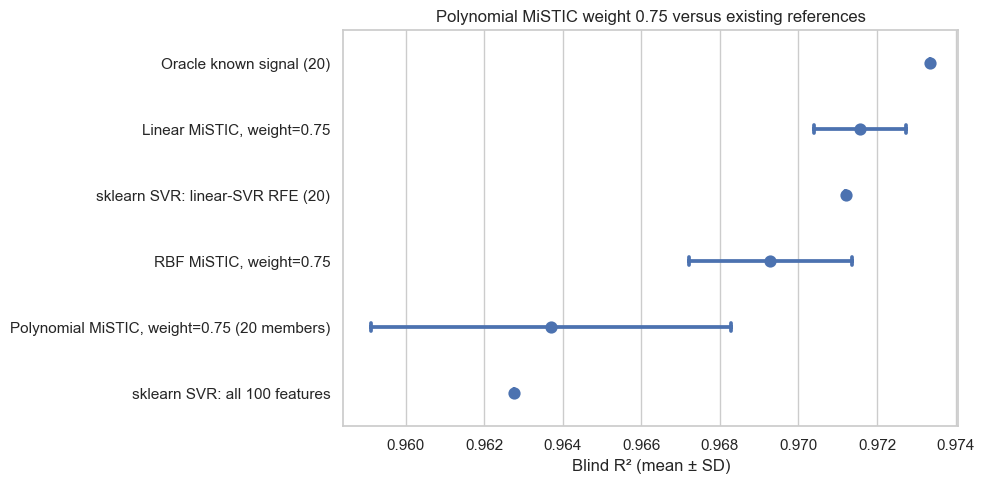

In [7]:
plot_frames = [results[["seed", "method", "r2"]]]
for label, frame in comparators.items():
    item = frame[["seed", "r2"]].copy()
    item["method"] = label
    plot_frames.append(item)
plot_data = pd.concat(plot_frames, ignore_index=True)
order = plot_data.groupby("method")["r2"].mean().sort_values(ascending=False).index
fig, ax = plt.subplots(figsize=(10, 5))
sns.pointplot(data=plot_data, y="method", x="r2", order=order,
              errorbar="sd", join=False, capsize=0.12, ax=ax)
ax.set_title("Polynomial MiSTIC weight 0.75 versus existing references")
ax.set_xlabel("Blind R² (mean ± SD)")
ax.set_ylabel("")
plt.tight_layout()
plot_path = repo_root / "validation/Synthetic100_regression_polynomial_rank075_20members_10seeds.png"
fig.savefig(plot_path, dpi=160, bbox_inches="tight")
plt.show()


## Interpretation notes

All ten model-building seeds share the same blind observations. Paired results
therefore describe sensitivity to inner splitting and selection, not
uncertainty over independently sampled test sets.
